# Modélisation du bruit de la chaîne ADC

In [158]:
# Constants definition

Fref = 125e6
Tmux = 34
#Fs, data_filename_ext = Fref, '_Fref.txt'
#Fs, data_filename_ext = Fref/(20), '_Frow.txt'
Fs, data_filename_ext = Fref / (20 * Tmux), '_Fframe.txt'


In [159]:
import types

import numpy as np
from scipy import constants


### Fonctions ###
def Celsius2Kelvin(TC):
    TK = TC + constants.zero_Celsius
    return TK


def thermal_noise(R, TK):
    en = np.sqrt(4 * constants.Boltzmann * R * TK)
    return en


def shot_noise(I):
    inn = np.sqrt(2 * constants.elementary_charge * I)
    return inn


def quantization_noise(Vpp, N, Fs):
    LSB = Vpp / 2 ** N
    RMS_q = LSB / np.sqrt(12)
    e_q = RMS_q / np.sqrt(Fs / 2)
    return e_q, RMS_q, LSB


def aliasing(noise_func, analog_bw, fs, n):
    if not isinstance(noise_func, types.FunctionType):
        print("noise_func n'est pas une fonction")
        return

    f_nyq = fs / 2

    if analog_bw < f_nyq:
        print("La bande analogique est inférieure à la fréquence de Nyquist")
        return

    #freqs numériques
    f_num = np.unique(np.round(np.logspace(0, np.ceil(np.log10(f_nyq)), n)))  #arrondi au Hz et unique
    f_num = f_num[f_num < f_nyq]
    f_num = np.append(f_num, f_nyq)  #on est sûr de pas dépasser la fréquence de nyquist et d'avoir un point dessus
    #on ajoute les repliement "impaire" Fs-f
    f_num = np.unique(np.sort(np.append(f_num, fs - f_num)))

    # Fréquence analogique (Hz)
    # ce sont les fréquences numériques périodisée sur toute la bande
    k_alias_max = np.ceil(analog_bw / fs)

    # Construction des alias
    k_alias = np.arange(0, k_alias_max + 1)[:, None]  # vecteur colonne
    f_analogique = f_num + k_alias * fs  # ajoute tous les multiples de Fs
    f_analogique = f_analogique[(f_analogique <= analog_bw)]  # ne garde que les fréquences inférieure

    # Tri final
    f_analogique = np.unique(
        np.sort(f_analogique))  #on s'assure de l'unicité (cas où on a une freq à 0 et Fs par exemple)

    # ==== CALCUL ====

    #repliement fréquentiel
    f_modulo = np.mod(f_analogique, fs)
    f_repliee = np.where(f_modulo > f_nyq, fs - f_modulo, f_modulo)

    #indices des fréquences identiques
    indices = np.searchsorted(f_num, f_repliee)

    # Somme des contributions
    e_fold_squared = np.zeros_like(f_analogique)
    e_vect = noise_func(2 * np.pi * f_analogique)
    np.add.at(e_fold_squared, indices, e_vect ** 2)

    # On prend la NSD mais que jusqu'à Fnyq
    ind_nyq = np.where(f_analogique == f_nyq)[0][0]  ## existe vu la définition de f_analogique
    f_num = f_analogique[:ind_nyq]
    e_fold = np.sqrt(e_fold_squared[:ind_nyq])

    return f_num, e_fold


def export_2vectors_to_file(x, y, filename):
    if len(x) != len(y):
        raise ValueError("The vectors have different sizes")
    with open(filename, 'w') as file:
        for i in range(len(x)):
            file.write('{0:}  {1:}\n'.format(x[i], y[i]))


## Bruit produit par les différents éléments
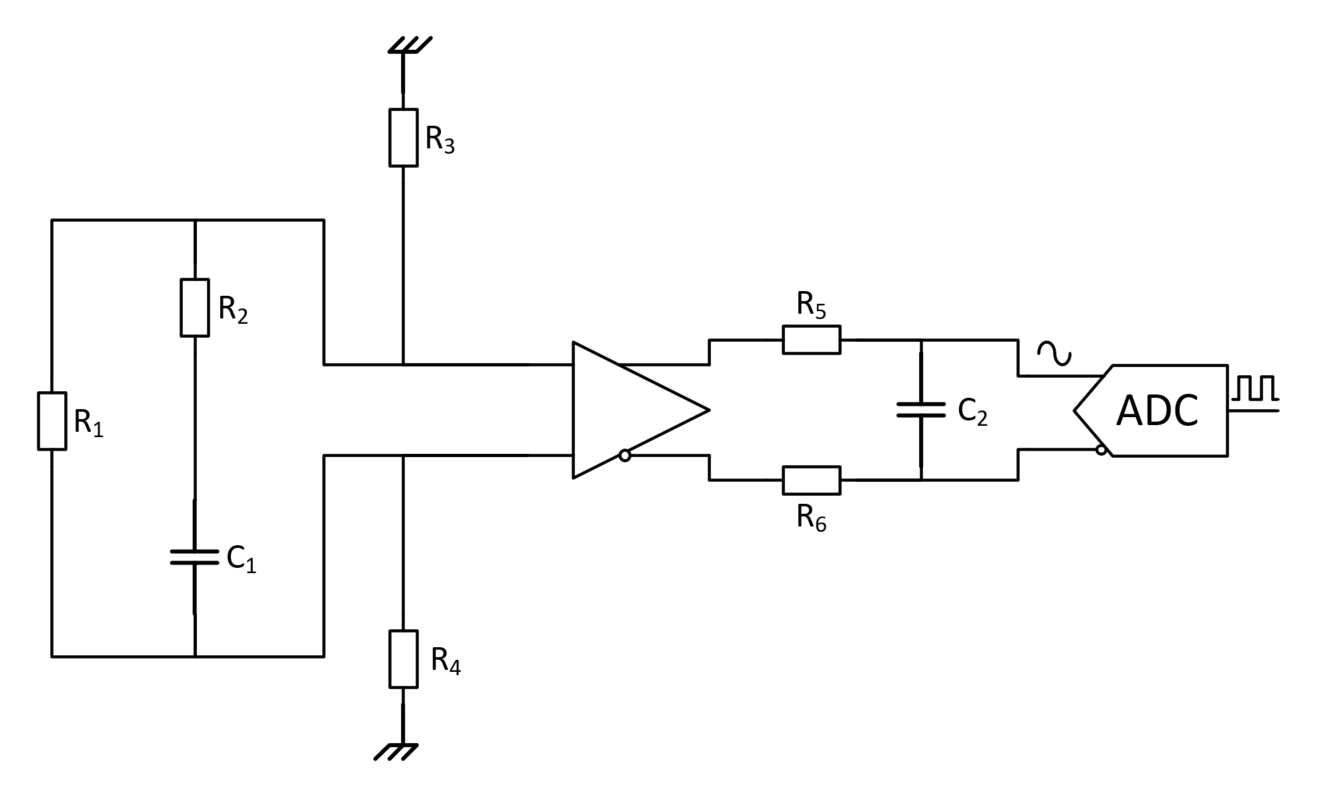

In [160]:
data_filename = 'erro-only' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R1 = 100
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er1 = thermal_noise(R1, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

# Gain des différents bruits

In [161]:
### Gain du LNA ###
gain_rhf = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1 + zequi_1(w)) * gain_rhf * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / R1 + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: R1 * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf * H_R56(w)

#Gain RHF200
H_rhf = lambda w: gain_rhf * H_R56(w)



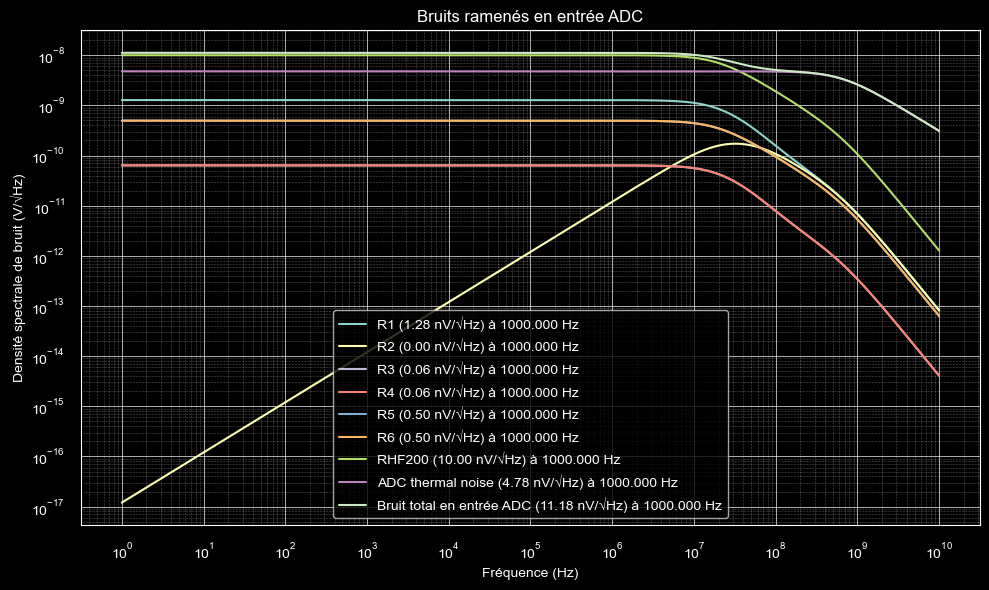

In [162]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
er1_out = lambda w: np.abs(H_R1(w)) * er1
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_out = lambda w: np.abs(H_rhf(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(
        w) ** 2 + erhf_out(w) ** 2 + e_adc_th_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_out(w), label=f"RHF200 ({erhf_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

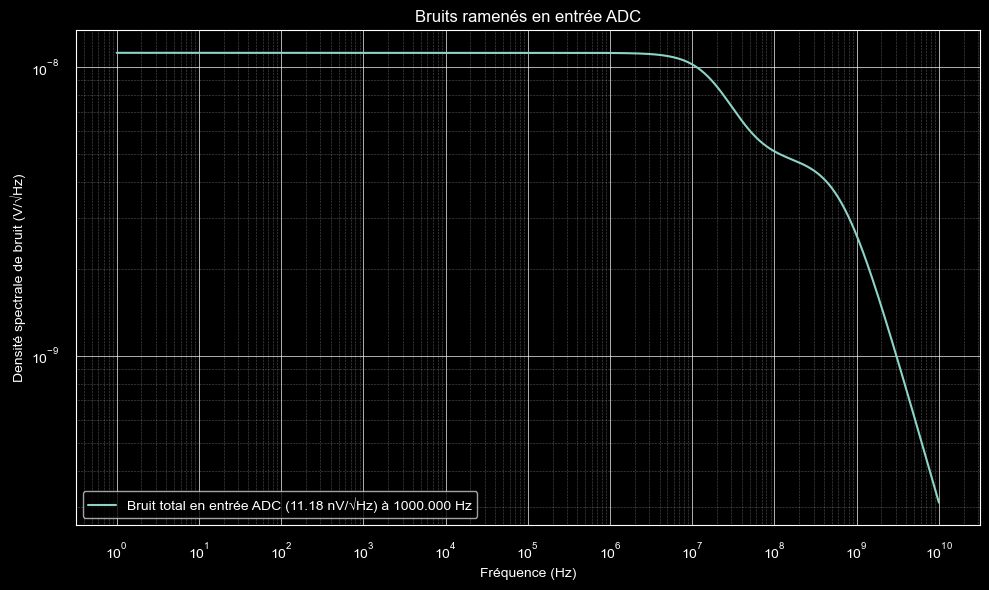

In [163]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

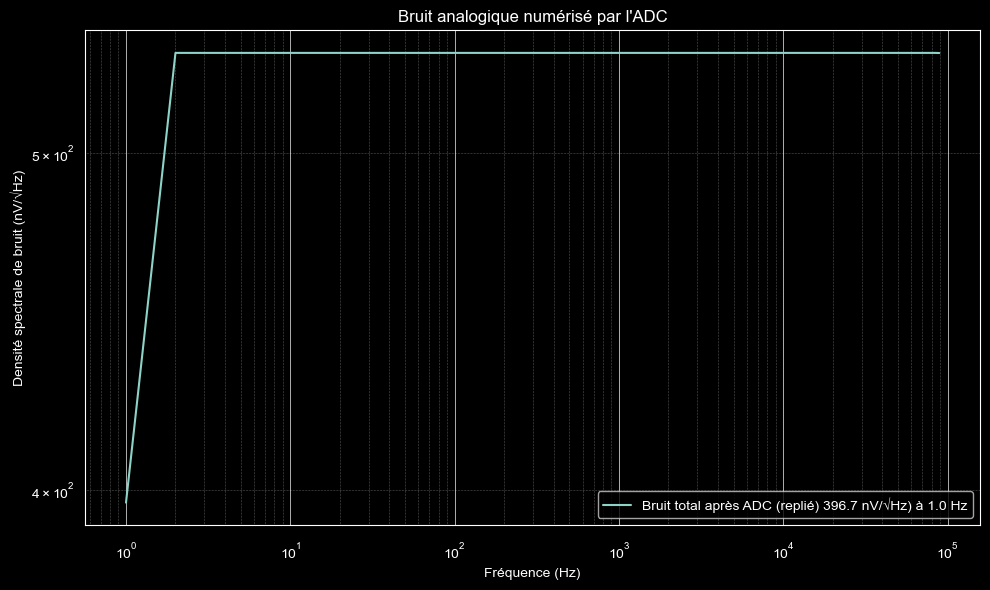

In [164]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

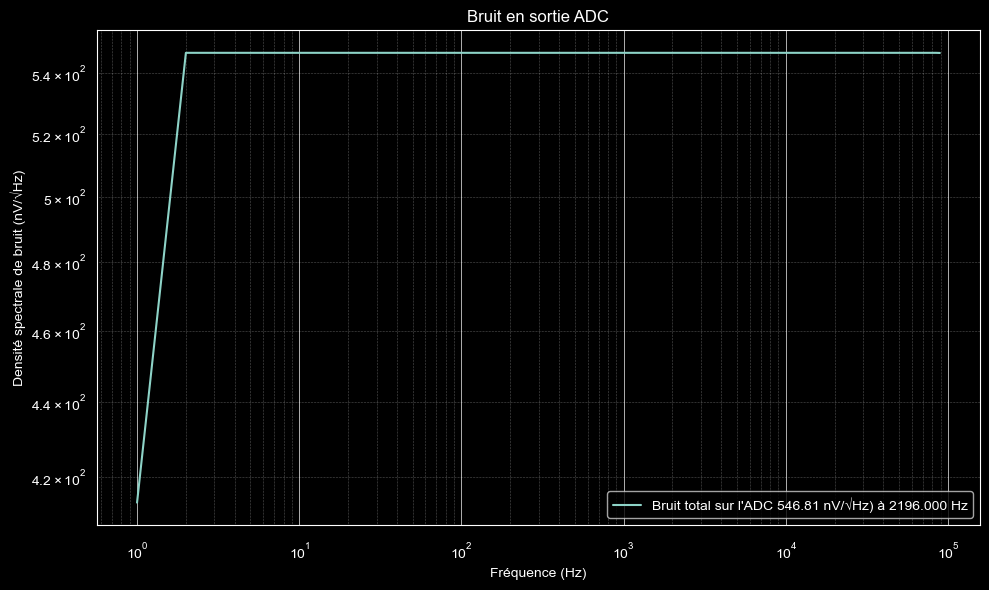

In [165]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [166]:
export_2vectors_to_file(f_num, e_total, data_filename)

# Bruit de la chaîne DAC FB rebouclé sur ADC

## 1. Awaxe

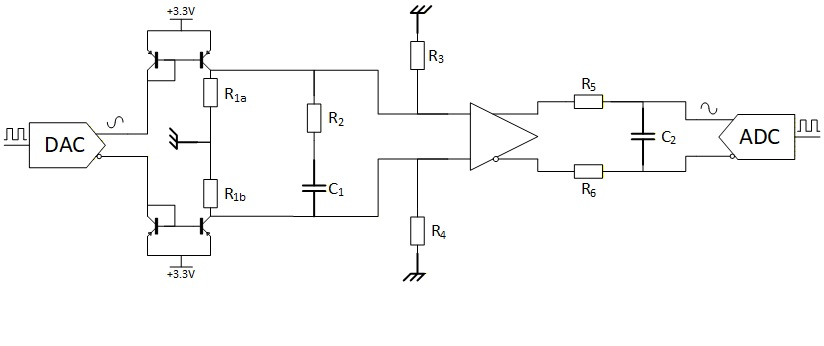

In [167]:
data_filename = 'erro-fdbk-awaxe' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R1a = 50
R1b = 50
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er1a = thermal_noise(R1a, Celsius2Kelvin(T))
er1b = thermal_noise(R1b, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#DAC
IDAC = 20e-3
in_DAC = shot_noise(IDAC)
#miroir de courant
in_mirror = np.sqrt(2) * in_DAC
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

### Gain des bruits

In [168]:
### Gain du RHF200 ###
gain_rhf = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1a + R1b + zequi_1(w)) * gain_rhf * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / (R1a + R1b) + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: (R1a + R1b) * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1a + R1b) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf * H_R56(w)

#Gain RHF200
H_rhf = lambda w: gain_rhf * H_R56(w)

#Gain Miroir de courant
H_current_mirror = lambda w: (R1a) * H_R1(w)  #Vrai seulement si R1a = R1b

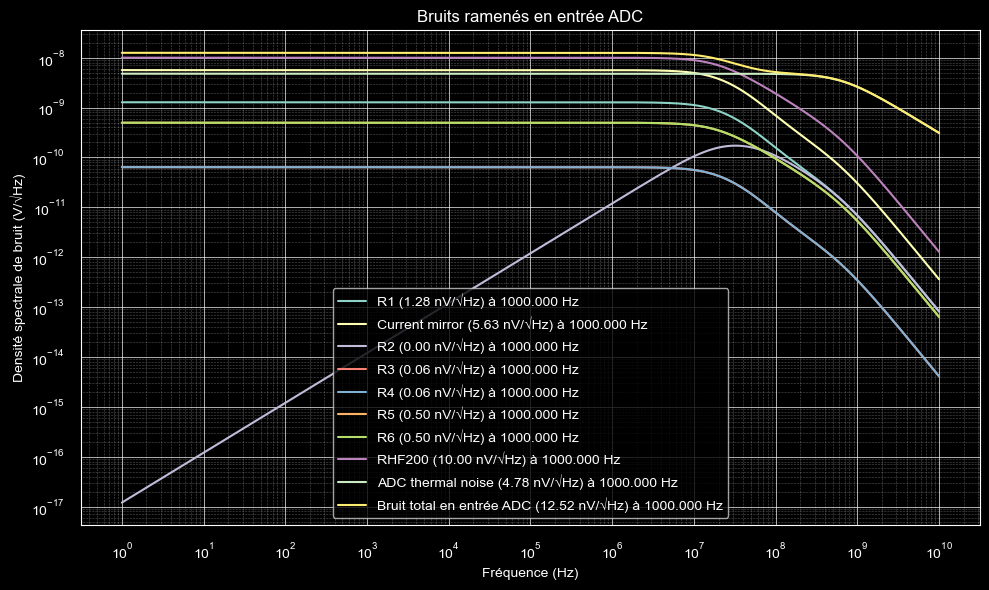

In [169]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
er1_out = lambda w: np.abs(H_R1(w)) * np.sqrt(er1a ** 2 + er1b ** 2)
e_miror_out = lambda w: np.abs(H_current_mirror(w)) * in_mirror
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_out = lambda w: np.abs(H_rhf(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(
        w) ** 2 + erhf_out(w) ** 2 + e_adc_th_out(w) ** 2 + e_miror_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_miror_out(w), label=f"Current mirror ({e_miror_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_out(w), label=f"RHF200 ({erhf_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

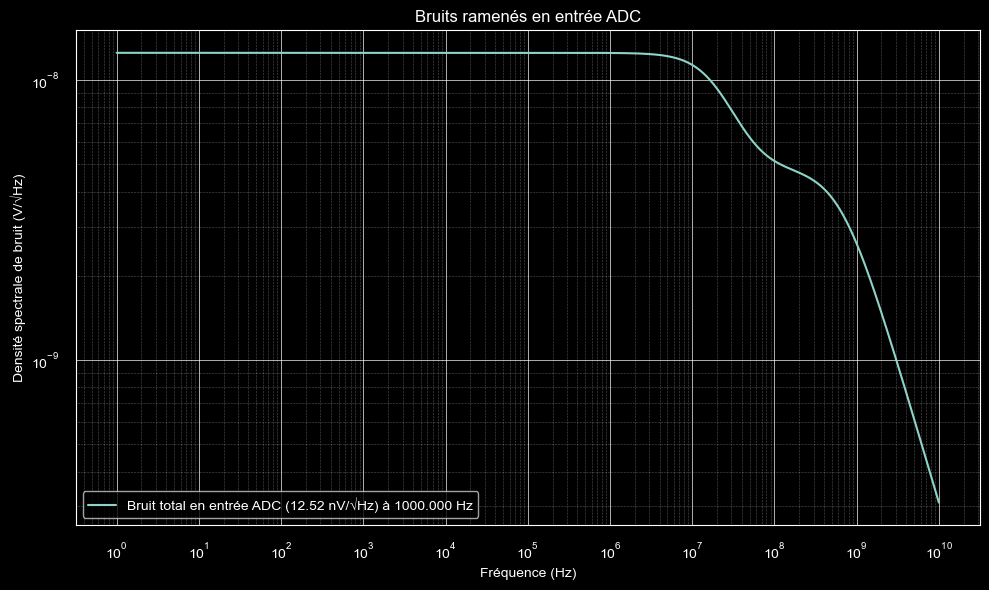

In [170]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

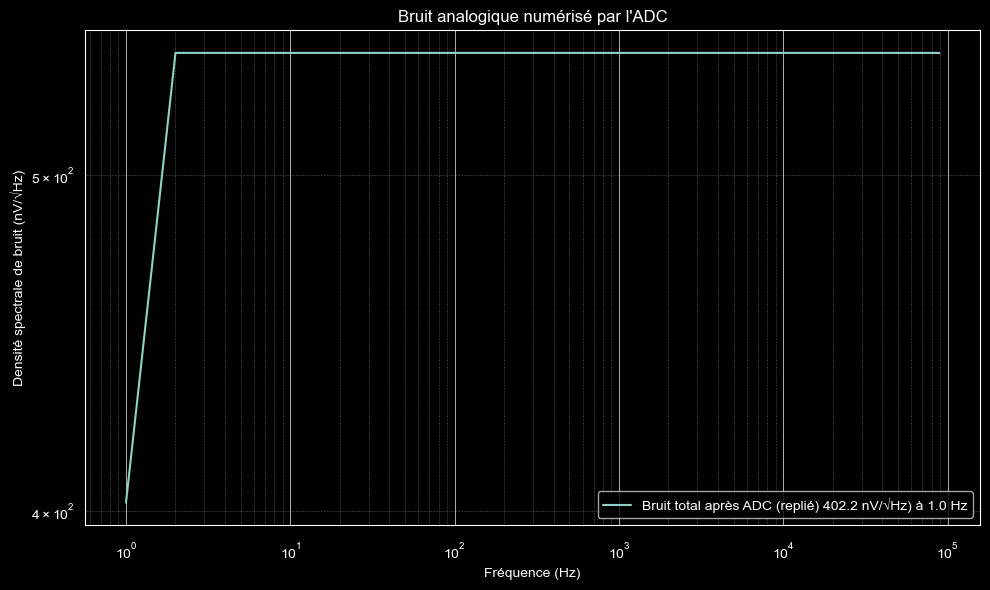

In [171]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

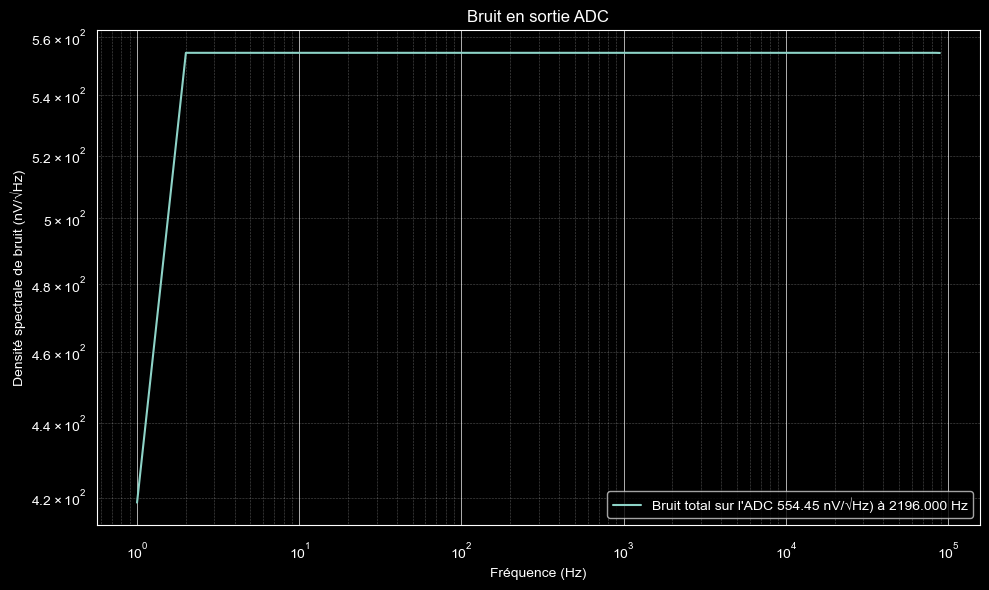

In [172]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [173]:
export_2vectors_to_file(f_num, e_total, data_filename)

## 2. RHF200

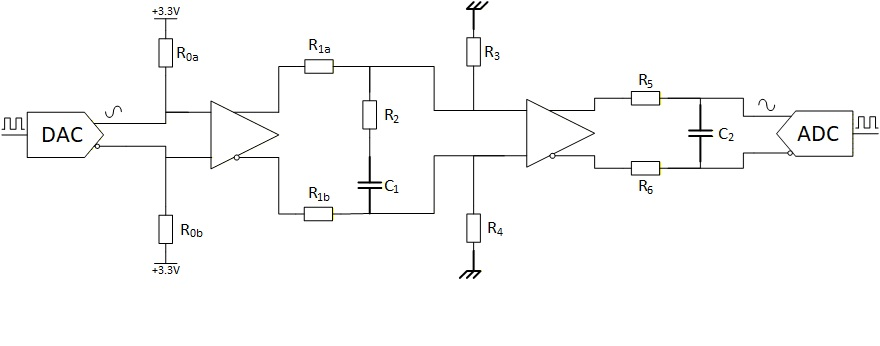

In [174]:
data_filename = 'erro-fdbk-rhf200' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R0a = 50
R0b = 50
R1a = 50
R1b = 50
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er0a = thermal_noise(R0a, Celsius2Kelvin(T))
er0b = thermal_noise(R0b, Celsius2Kelvin(T))
er1a = thermal_noise(R1a, Celsius2Kelvin(T))
er1b = thermal_noise(R1b, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#DAC
IDAC = 20e-3
in_DAC = shot_noise(IDAC)
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

# Gain des bruits

In [175]:
### Gain du RHF200 ###
gain_rhf_adc = 1
gain_rhf_dac = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1a + R1b + zequi_1(w)) * gain_rhf_adc * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / (R1a + R1b) + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf_adc * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: (R1a + R1b) * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1a + R1b) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf_adc * H_R56(w)

#Gain RHF200 ADC
H_rhf_adc = lambda w: H_R56(w)

#Gain RHF200 DAC
H_rhf_dac = lambda w: H_R1(w)

#Gain R0
H_R0 = lambda w: gain_rhf_dac * H_rhf_dac(w)

#Gain DAC
H_dac = lambda w: R0a * gain_rhf_dac * H_rhf_dac(w)

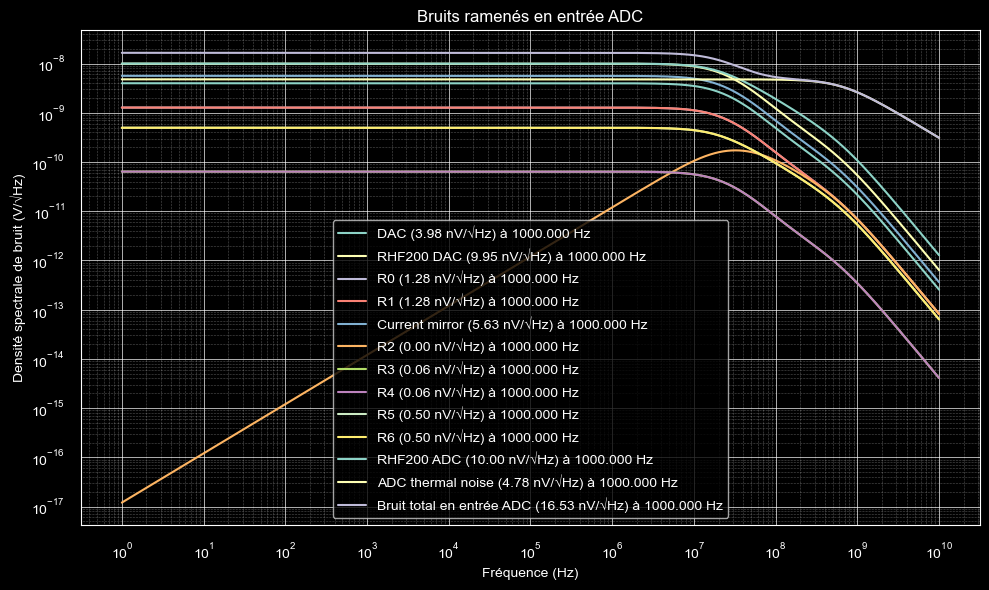

In [176]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
e_dac_out = lambda w: np.abs(H_dac(w)) * in_DAC
erhf_dac_out = lambda w: np.abs(H_rhf_dac(w)) * e_rhf_o
er0_out = lambda w: np.abs(H_R0(w)) * np.sqrt(er0a ** 2 + er0b ** 2)
er1_out = lambda w: np.abs(H_R1(w)) * np.sqrt(er1a ** 2 + er1b ** 2)
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_adc_out = lambda w: np.abs(H_rhf_adc(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    e_dac_out(w) ** 2 + erhf_dac_out(w) ** 2 + er0_out(w) ** 2 + er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(
        w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(w) ** 2 + erhf_adc_out(w) ** 2 + e_adc_th_out(
        w) ** 2 + e_miror_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_dac_out(w), label=f"DAC ({e_dac_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_dac_out(w), label=f"RHF200 DAC ({erhf_dac_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er0_out(w), label=f"R0 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_miror_out(w), label=f"Current mirror ({e_miror_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_adc_out(w), label=f"RHF200 ADC ({erhf_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

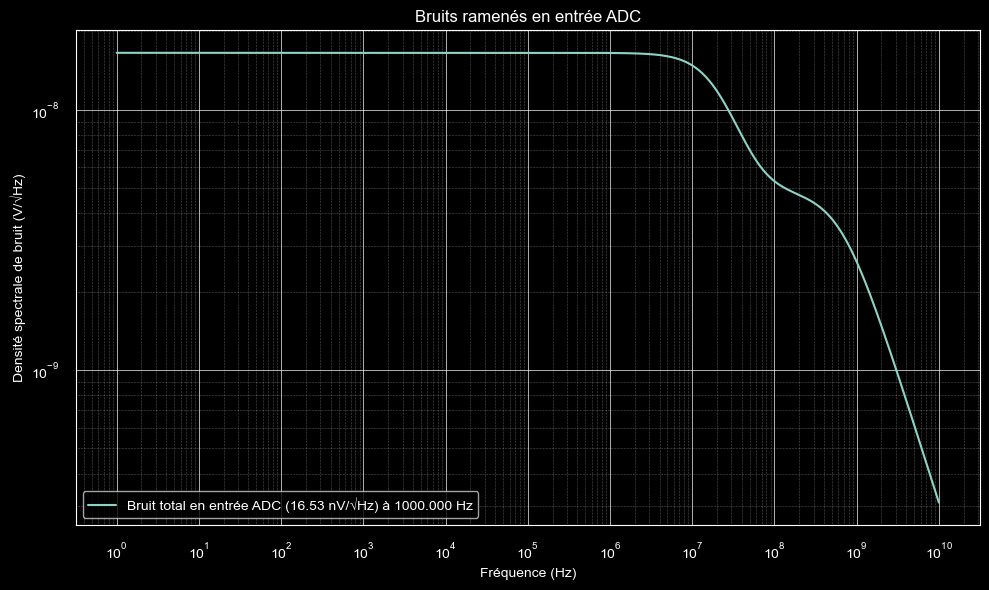

In [177]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

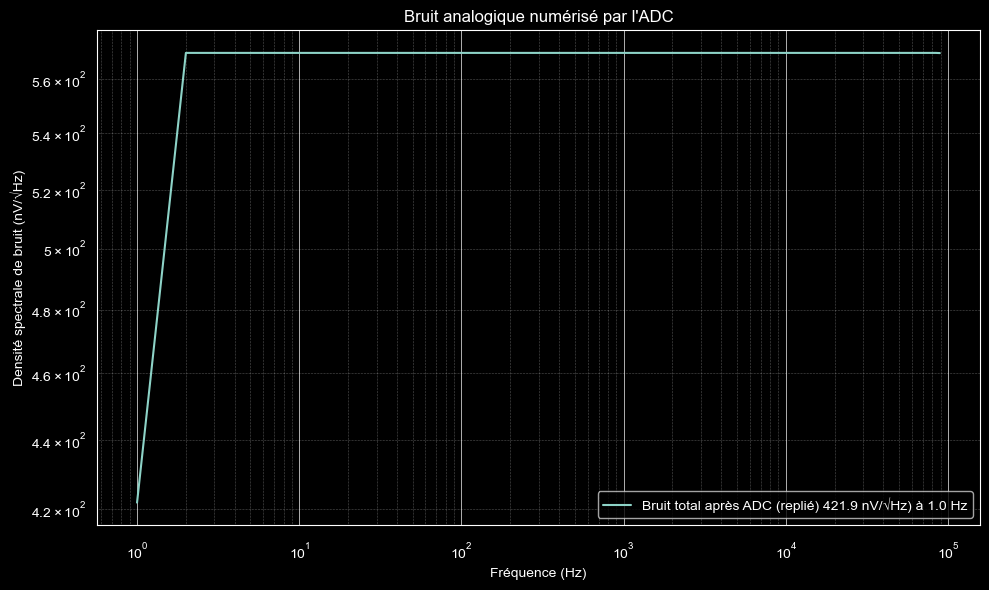

In [178]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

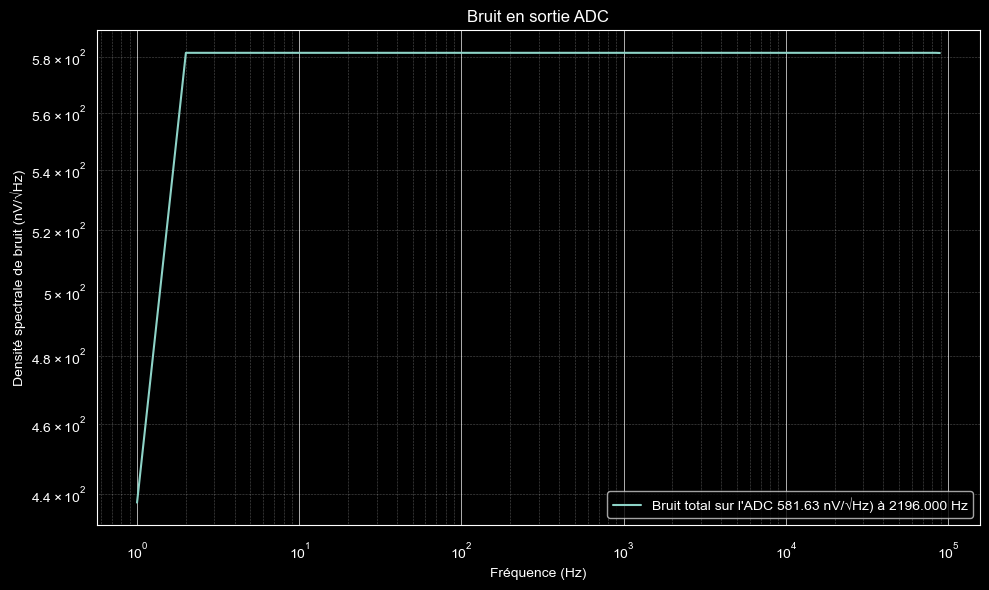

In [179]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [180]:
export_2vectors_to_file(f_num, e_total, data_filename)